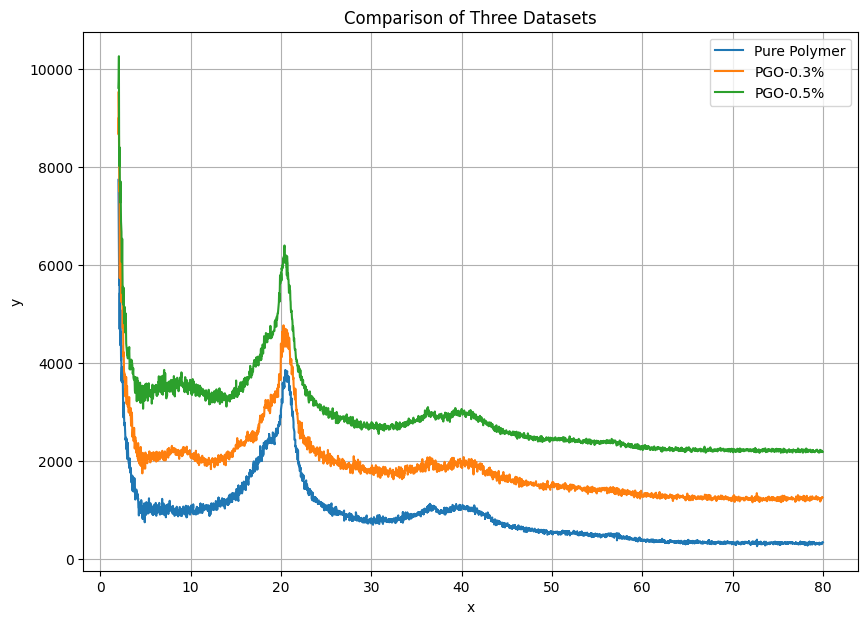

Noise Analysis
PGO-0.3% noise SD : 60.7901
PGO-0.5% noise SD : 48.6030
Noise correlation : 0.0849
Noise scale       : 1.2507

Synthetic dataset saved:
PGO-0.3_synthetic_noise_pattern_from_0.5.txt


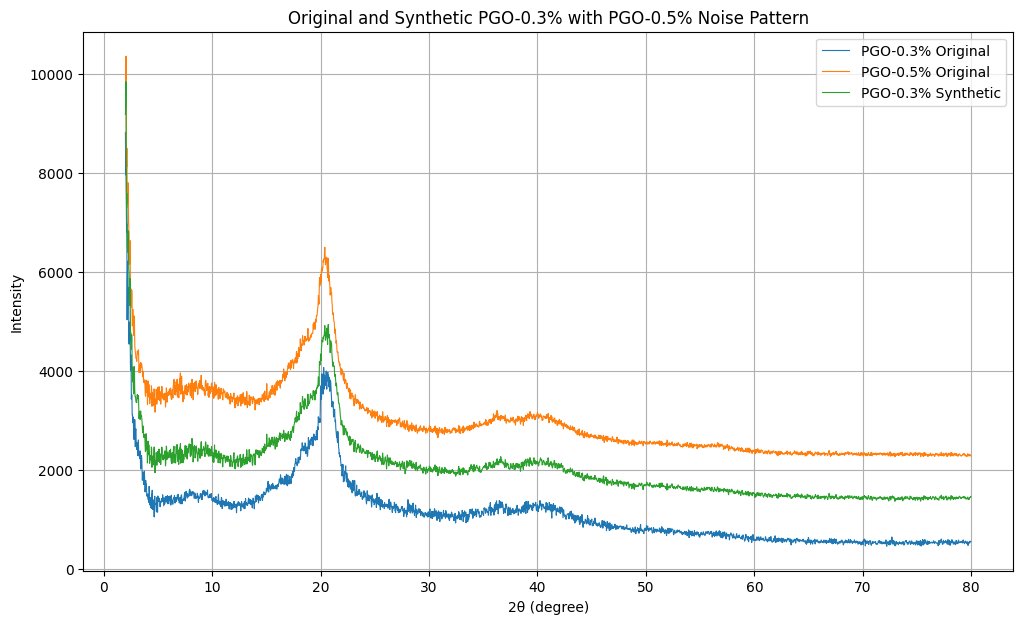

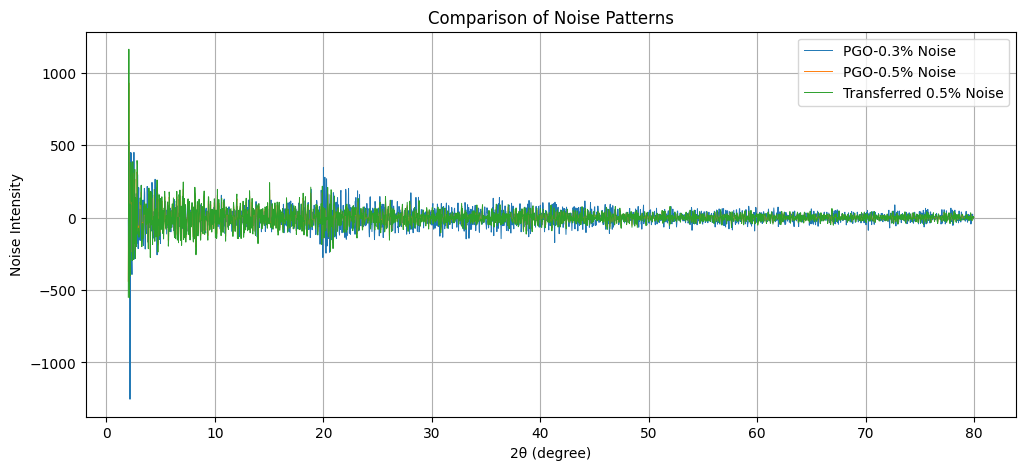


Noise Summary
              Metric      Value
0  PGO-0.3% Noise SD  60.790130
1  PGO-0.5% Noise SD  48.602985
2        Noise Scale   1.250749
3  Noise Correlation   0.084867


In [2]:
# =====================================
# Data Read
# =====================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import savgol_filter


def read_data(filename, encoding):
    return pd.read_csv(
        filename,
        sep=r"\s+",
        header=None,
        names=["x", "y"],
        encoding=encoding,
        engine="python"
    )


# -------------------------------------
# Read datasets
# -------------------------------------

df1 = read_data("Pure Polymer.txt", "utf-8")
df2 = read_data("PGO-0.3%.txt", "utf-8")
df3 = read_data("PGO-0.5%.txt", "utf-16")


# =====================================
# Original Plot
# =====================================

plt.figure(figsize=(10, 7))

plt.plot(
    df1["x"],
    df1["y"],
    label="Pure Polymer"
)

plt.plot(
    df2["x"],
    df2["y"] + 700,
    label="PGO-0.3%"
)

plt.plot(
    df3["x"],
    df3["y"] + 1800,
    label="PGO-0.5%"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Comparison of Three Datasets")

plt.legend()
plt.grid(True)

plt.show()


# =====================================
# Noise Pattern Analysis
# =====================================

# Convert to NumPy arrays

x03 = df2["x"].to_numpy()
y03 = df2["y"].to_numpy()

x05 = df3["x"].to_numpy()
y05 = df3["y"].to_numpy()


# =====================================
# Align PGO-0.5% to PGO-0.3% X-axis
# =====================================

y05_aligned = np.interp(
    x03,
    x05,
    y05
)


# =====================================
# Extract Signal + Noise
# =====================================

# Savitzky-Golay parameters

window_length = 21
polyorder = 3


# Smoothed signals

signal03 = savgol_filter(
    y03,
    window_length=window_length,
    polyorder=polyorder
)

signal05 = savgol_filter(
    y05_aligned,
    window_length=window_length,
    polyorder=polyorder
)


# Extract high-frequency noise

noise03 = y03 - signal03
noise05 = y05_aligned - signal05


# =====================================
# Noise Statistics
# =====================================

std_noise03 = np.std(noise03)
std_noise05 = np.std(noise05)


print("=====================================")
print("Noise Analysis")
print("=====================================")

print(f"PGO-0.3% noise SD : {std_noise03:.4f}")
print(f"PGO-0.5% noise SD : {std_noise05:.4f}")


# =====================================
# Correlation Between Noise Patterns
# =====================================

noise_correlation = np.corrcoef(
    noise03,
    noise05
)[0, 1]


print(f"Noise correlation : {noise_correlation:.4f}")


# =====================================
# Scale 0.5% Noise to 0.3% Noise Level
# =====================================

noise_scale = std_noise03 / std_noise05


print(f"Noise scale       : {noise_scale:.4f}")


# Apply scaling

transferred_noise = noise05 * noise_scale


# =====================================
# Create Synthetic PGO-0.3%
# =====================================

y03_synthetic = (
    signal03
    + transferred_noise
)


# =====================================
# Create DataFrame
# =====================================

df03_synthetic = pd.DataFrame({
    "x": x03,
    "y": y03_synthetic
})


# =====================================
# Save Synthetic Dataset
# =====================================

df03_synthetic.to_csv(
    "PGO-0.3_synthetic_noise_pattern_from_0.5.txt",
    sep="\t",
    index=False,
    header=False,
    float_format="%.8f"
)


print()
print("Synthetic dataset saved:")
print("PGO-0.3_synthetic_noise_pattern_from_0.5.txt")


# =====================================
# Plot:
# Original 0.3%
# Original 0.5%
# Synthetic 0.3%
# =====================================

plt.figure(figsize=(12, 7))

plt.plot(
    x03,
    y03,
    label="PGO-0.3% Original",
    linewidth=0.8
)

plt.plot(
    x05,
    y05 + 1900,
    label="PGO-0.5% Original",
    linewidth=0.8
)

plt.plot(
    x03,
    y03_synthetic + 900,
    label="PGO-0.3% Synthetic",
    linewidth=0.8
)

plt.xlabel("2θ (degree)")
plt.ylabel("Intensity")

plt.title(
    "Original and Synthetic PGO-0.3% "
    "with PGO-0.5% Noise Pattern"
)

plt.legend()
plt.grid(True)

plt.show()


# =====================================
# Plot Noise Patterns
# =====================================

plt.figure(figsize=(12, 5))

plt.plot(
    x03,
    noise03,
    label="PGO-0.3% Noise",
    linewidth=0.7
)

plt.plot(
    x03,
    noise05,
    label="PGO-0.5% Noise",
    linewidth=0.7
)

plt.plot(
    x03,
    transferred_noise,
    label="Transferred 0.5% Noise",
    linewidth=0.7
)

plt.xlabel("2θ (degree)")
plt.ylabel("Noise Intensity")

plt.title("Comparison of Noise Patterns")

plt.legend()
plt.grid(True)

plt.show()


# =====================================
# Comparison Table
# =====================================

noise_summary = pd.DataFrame({
    "Metric": [
        "PGO-0.3% Noise SD",
        "PGO-0.5% Noise SD",
        "Noise Scale",
        "Noise Correlation"
    ],
    "Value": [
        std_noise03,
        std_noise05,
        noise_scale,
        noise_correlation
    ]
})


print()
print("=====================================")
print("Noise Summary")
print("=====================================")

print(noise_summary)


# =====================================
# Save Noise Analysis
# =====================================

noise_summary.to_csv(
    "PGO_noise_pattern_comparison.csv",
    index=False
)